<a href="https://colab.research.google.com/github/InahH-004/PCD_Collage/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
!kaggle --version

Kaggle CLI 2.0.2


#Import Dataset

In [46]:
import kagglehub

path = kagglehub.dataset_download("oddyvirgantara/dataset-tutorial-pcd")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dataset-tutorial-pcd' dataset.
Path to dataset files: /kaggle/input/dataset-tutorial-pcd


In [47]:
import os

files = os.listdir(path)
print("Jumlah file : ", len(files))
print(files)


Jumlah file :  9
['wdg3.png', 'dog_dark.jpg', 'pollen_low_contrast.jpg', 'image1.png', 'book.jpg', 'cameraman.png', 'grain_noise.jpg', '975-1.jpg', '974-1.jpg']


#Down-Sampling

##Max-Downsampling

In [48]:
def max_downsampling(img, scale):
    h = len(img) #tinggi citra
    w = len(img[0]) #lebar citra
    c = len(img[0][0]) #channel citra

    h_baru = h // scale
    w_baru = w // scale

    #tempat menaruh hasil downsampling nya nanti
    output = [[[0] * c for _ in range(w_baru)] for _ in range(h_baru)]

    #Perulangan fitur Slicing
    for i in range(h_baru):
        for j in range(w_baru):
            for k in range(c):
                 #Batas baris awal dan akhir
                  r_awal = i * scale
                  r_akhir = r_awal + scale

                  #batas kolom awal dan akhir
                  c_awal = j * scale
                  c_akhir = c_awal + scale

                  #inisiasi nilai max
                  nilai_max = 0

                  #proses perbandingan nilai

                  #untuk tiap nilai baris dari awal sampai akhir
                  for r in range(r_awal, r_akhir):

                      #untuk tiap channel citra dari awal smpe akhir
                      for col in range(c_awal, c_akhir):
                          #tentukan nilai max dari img nya
                          nilai_max = max(nilai_max, img[r][col][k])

                  #output dari perbandingan nilai max itu
                  output[i][j][k] = nilai_max

    return output



##Average Downsampling

In [49]:
def avg_downsampling(img, scale):
    h = len(img) #tinggi citra
    w = len(img[0]) #lebar citra
    c = len(img[0][0]) #channel citra

    h_baru = h // scale
    w_baru = w // scale

    #tempat menaruh hasil downsampling nya nanti
    output = [[[0] * c for _ in range(w_baru)] for _ in range(h_baru)]

    #Perulangan fitur Slicing
    for i in range(h_baru):
        for j in range(w_baru):
            for k in range(c):
                 #Batas baris awal dan akhir
                  r_awal = i * scale
                  r_akhir = r_awal + scale

                  #batas kolom awal dan akhir
                  c_awal = j * scale
                  c_akhir = c_awal + scale

                  #inisiasi total nilai
                  total_nilai = 0

                  #proses perbandingan nilai

                  #untuk tiap nilai baris dari awal sampai akhir
                  for r in range(r_awal, r_akhir):

                      #untuk tiap channel citra dari awal smpe akhir
                      for col in range(c_awal, c_akhir):
                          #tentukan nilai total dari img nya
                          total_nilai += int(img[r][col][k])

                  #output menghitung avg dari total nilai yg didapat
                  avg_nilai = round(total_nilai / (scale * scale))
                  output[i][j][k] = avg_nilai

    return output



##Median Downsampling

In [50]:
def med_downsampling(img, scale):
    h = len(img) #tinggi citra
    w = len(img[0]) #lebar citra
    c = len(img[0][0]) #channel citra

    h_baru = h // scale
    w_baru = w // scale

    #tempat menaruh hasil downsampling nya nanti
    output = [[[0] * c for _ in range(w_baru)] for _ in range(h_baru)]

    #Perulangan fitur Slicing
    for i in range(h_baru):
        for j in range(w_baru):
            for k in range(c):
                 #Batas baris awal dan akhir
                  r_awal = i * scale
                  r_akhir = r_awal + scale

                  #batas kolom awal dan akhir
                  c_awal = j * scale
                  c_akhir = c_awal + scale

                  #inisiasi total nilai
                  daftar_piksel = []

                  #proses perbandingan nilai

                  #untuk tiap nilai baris dari awal sampai akhir
                  for r in range(r_awal, r_akhir):

                      #untuk tiap channel citra dari awal smpe akhir
                      for col in range(c_awal, c_akhir):
                          #tentukan nilai total dari img nya
                          daftar_piksel.append(img[r][col][k])

                  #urutkan daftar piksel
                  daftar_piksel.sort()
                  if len(daftar_piksel) % 2 == 0:
                      median = (int(daftar_piksel[len(daftar_piksel) // 2]) + int(daftar_piksel[len(daftar_piksel) // 2 - 1])) // 2
                  else:
                      median = daftar_piksel[len(daftar_piksel) // 2]
                  output[i][j][k] = median

    return output



#Up Sampling

##Nearest Neighboor

In [51]:
def nn_upsampling(img, scale):
    h = len(img) #tinggi citra
    w = len(img[0]) #lebar citra
    c = len(img[0][0]) #channel citra

    h_baru = h * scale
    w_baru = w * scale

    #tempat menaruh hasil upsampling nya nanti
    output = [[[0] * c for _ in range(w_baru)] for _ in range(h_baru)]

    #Perulangan fitur
    for i in range(h_baru):
        for j in range(w_baru):

            r_asli = min(round(i / scale), h - 1)
            c_asli = min(round(j / scale), w - 1)

            for k in range(c):
                  output[i][j][k] = img[r_asli][c_asli][k]

    return output

## Bilinear Interpolation Upsampling

In [52]:
def bilinear_upsampling(img, scale):
    h = len(img) #tinggi citra
    w = len(img[0]) #lebar citra
    c = len(img[0][0]) #channel citra

    h_baru = h * scale
    w_baru = w * scale

    #tempat menaruh hasil upsampling nya nanti
    output = [[[0] * c for _ in range(w_baru)] for _ in range(h_baru)]

    for i in range(h_baru):
        for j in range(w_baru):

           r_asli = i / scale
           c_asli = j / scale

           r_acuan = min(int(r_asli), h - 1)
           c_acuan = min(int(c_asli), w - 1)

           r_tetangga = min(r_acuan + 1, h - 1)
           c_tetangga = min(c_acuan + 1, w - 1)

           r_interpolasi = r_asli - int(r_asli)
           c_interpolasi = c_asli - int(c_asli)

           for k in range(c):
                Q11 = img[r_acuan][c_acuan][k]
                Q12 = img[r_acuan][c_tetangga][k]
                Q21 = img[r_tetangga][c_acuan][k]
                Q22 = img[r_tetangga][c_tetangga][k]

                #interpolasi horizontal
                r_atas = Q11 * (1 - c_interpolasi) + Q12 * c_interpolasi
                r_bawah = Q21 * (1 - c_interpolasi) + Q22 * c_interpolasi

                #interpolasi vertikal
                nilai_akhir = r_atas * (1 - r_interpolasi) + r_bawah * r_interpolasi

                output[i][j][k] = max(0, min(255, round(nilai_akhir)))

    return output

##Bicubic

In [53]:
def bicubic_upsampling(img, scale):
    def bobot_kubic(d):
        if d <= 1:
            return 1.5 * d ** 3 - 2.5 * (d ** 2) + 1
        elif 1 < d < 2:
            return -0.5 * d ** 3 + 2.5 * (d ** 2) - 4 * d + 2
        else:
            return 0.0

    h = len(img) #tinggi citra
    w = len(img[0]) #lebar citra
    c = len(img[0][0]) #channel citra

    h_baru = h * scale
    w_baru = w * scale

    output = [[[0] * c for _ in range(w_baru)] for _ in range(h_baru)]

    for i in range(h_baru):
        for j in range(w_baru):
            r_asli = i / scale
            c_asli = j / scale

            r_acuan = int(r_asli)
            c_acuan = int(c_asli)

            r_fraksional = r_asli - r_acuan
            c_fraksional = c_asli - c_acuan

            # 4 indeks baris (r) dan kolom (c)
            daftar_r = [max(0, min(h-1, r_acuan + m)) for m in range(-1, 3)]
            daftar_c = [max(0, min(w-1, c_acuan + n))for n in range(-1, 3)]

            bobot_r = [bobot_kubic(abs(r_fraksional - m)) for m in range(-1, 3)]
            bobot_c = [bobot_kubic(abs(c_fraksional - n)) for n in range(-1, 3)]

            for k in range(c):
                total_nilai = 0.0

                #menelusuri 4x4 tetangga
                for m_idx in range(4):
                    for n_idx in range(4):
                        baris_target = daftar_r[m_idx]
                        kolom_target = daftar_c[n_idx]

                        piksel = img[baris_target][kolom_target][k]
                        total_nilai += piksel * bobot_r[m_idx] * bobot_c[n_idx]

                output[i][j][k] = max(0, min(255, round(total_nilai)))

    return output


#Image


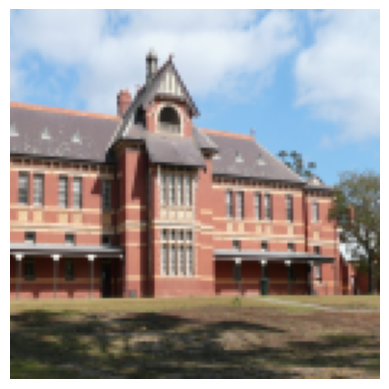

In [54]:
import cv2
import matplotlib.pyplot as plt
import os

image_name =  '975-1.jpg'
image_path = os.path.join(path, image_name)
img = cv2.imread(image_path) #by default BGR

#konversi ke format rgb
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize ke 128 x 128
target_size = (128, 128)
img_resized = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_AREA)

plt.axis('off')
plt.imshow(img_resized)

#Aplikasi

Down sampling 2x dan 4x dari Gambar Asli

<function matplotlib.pyplot.show(close=None, block=None)>

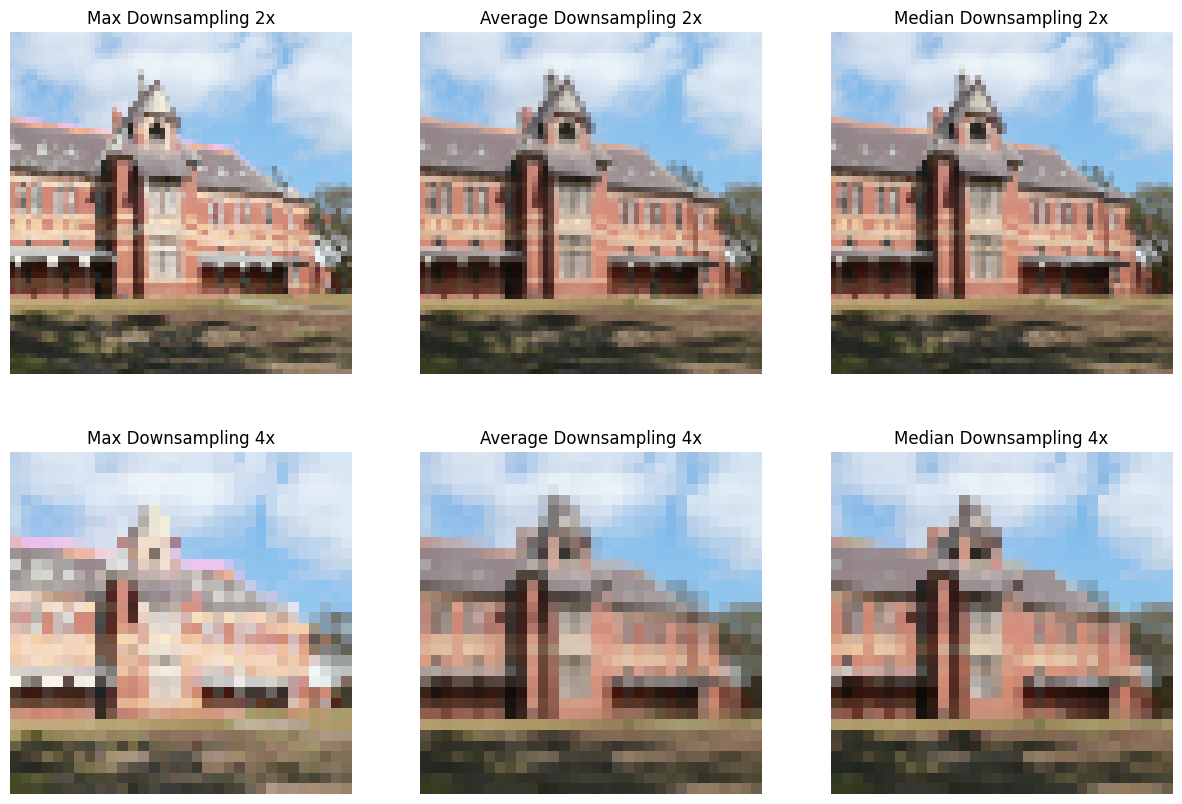

In [55]:
import matplotlib.pyplot as plt
import numpy as np

#down sampling
img_max_downsampling = max_downsampling(img_resized, 2)
img_avg_downsampling = avg_downsampling(img_resized, 2)
img_med_downsampling = med_downsampling(img_resized, 2)

img_max_downsampling_4 = max_downsampling(img_resized, 4)
img_avg_downsampling_4 = avg_downsampling(img_resized, 4)
img_med_downsampling_4 = med_downsampling(img_resized, 4)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

#Hasil down sampling
axs[0][0].imshow(img_max_downsampling)
axs[0][0].set_title('Max Downsampling 2x')
axs[0][0].axis('off')

axs[0][1].imshow(img_avg_downsampling)
axs[0][1].set_title('Average Downsampling 2x')
axs[0][1].axis('off')

axs[0][2].imshow(img_med_downsampling)
axs[0][2].set_title('Median Downsampling 2x')
axs[0][2].axis('off')

axs[1][0].imshow(img_max_downsampling_4)
axs[1][0].set_title('Max Downsampling 4x')
axs[1][0].axis('off')

axs[1][1].imshow(img_avg_downsampling_4)
axs[1][1].set_title('Average Downsampling 4x')
axs[1][1].axis('off')

axs[1][2].imshow(img_med_downsampling_4)
axs[1][2].set_title('Median Downsampling 4x')
axs[1][2].axis('off')


plt.show


Upsampling dari Gambar Asli 2x dan 4x

<function matplotlib.pyplot.show(close=None, block=None)>

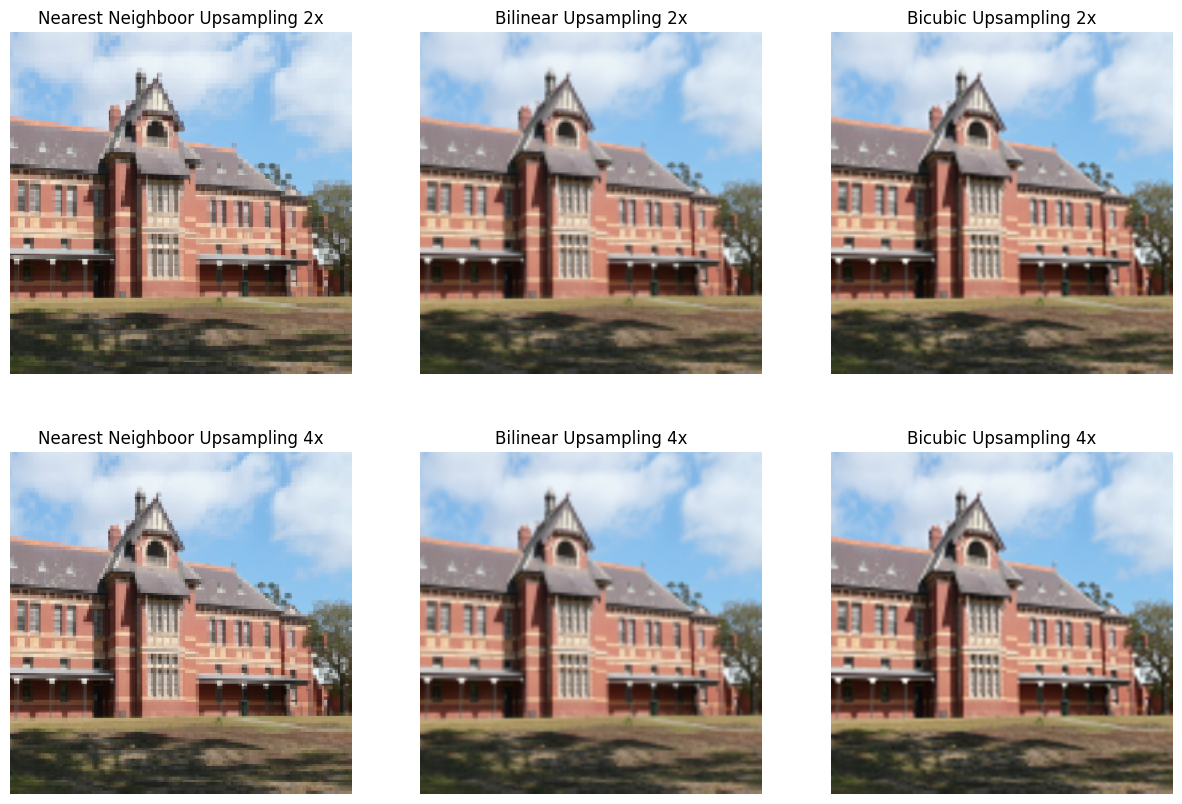

In [56]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

#up sampling

img_nn_upsampling = nn_upsampling(img_resized, 2)
img_bilinear_upsampling = bilinear_upsampling(img_resized, 2)
img_bicubic_upsampling = bicubic_upsampling(img_resized, 2)

img_nn_upsampling_4 = nn_upsampling(img_resized, 4)
img_bilinear_upsampling_4 = bilinear_upsampling(img_resized, 4)
img_bicubic_upsampling_4 = bicubic_upsampling(img_resized, 4)

#Hasil Up sampling
axs[0][0].imshow(img_nn_upsampling)
axs[0][0].set_title('Nearest Neighboor Upsampling 2x')
axs[0][0].axis('off')

axs[0][1].imshow(img_bilinear_upsampling)
axs[0][1].set_title('Bilinear Upsampling 2x')
axs[0][1].axis('off')

hasil_bicubic = np.array(img_bicubic_upsampling, dtype=np.uint8)

axs[0][2].imshow(hasil_bicubic)
axs[0][2].set_title('Bicubic Upsampling 2x')
axs[0][2].axis('off')

axs[1][0].imshow(img_nn_upsampling_4)
axs[1][0].set_title('Nearest Neighboor Upsampling 4x')
axs[1][0].axis('off')

axs[1][1].imshow(img_bilinear_upsampling_4)
axs[1][1].set_title('Bilinear Upsampling 4x')
axs[1][1].axis('off')

hasil_bicubic_4 = np.array(img_bicubic_upsampling_4, dtype=np.uint8)

axs[1][2].imshow(hasil_bicubic_4)
axs[1][2].set_title('Bicubic Upsampling 4x')
axs[1][2].axis('off')

plt.show




Upscalling 4x dari Gambar Hasil max downsampling 4x

<function matplotlib.pyplot.show(close=None, block=None)>

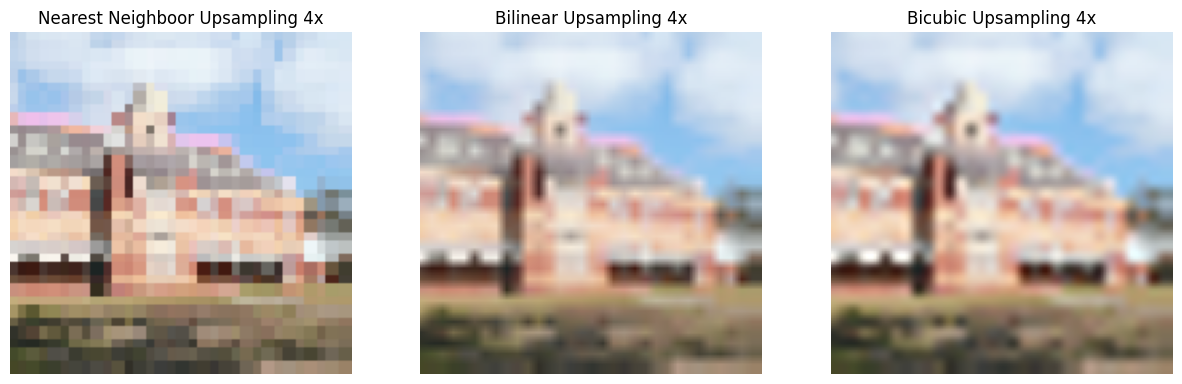

In [57]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(15, 10))

img_nn_upsampling_4 = nn_upsampling(img_max_downsampling_4, 4)
img_bilinear_upsampling_4 = bilinear_upsampling(img_max_downsampling_4, 4)
img_bicubic_upsampling_4 = bicubic_upsampling(img_max_downsampling_4, 4)

axs[0].imshow(img_nn_upsampling_4)
axs[0].set_title('Nearest Neighboor Upsampling 4x')
axs[0].axis('off')

axs[1].imshow(img_bilinear_upsampling_4)
axs[1].set_title('Bilinear Upsampling 4x')
axs[1].axis('off')

hasil_bicubic_4 = np.array(img_bicubic_upsampling_4, dtype=np.uint8)

axs[2].imshow(hasil_bicubic_4)
axs[2].set_title('Bicubic Upsampling 4x')
axs[2].axis('off')

plt.show